<a href="https://colab.research.google.com/github/20252025202/Calculator-/blob/main/Rice_Leaf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Generating a synthetic dataset to ensure the code runs perfectly
np.random.seed(42)
data_size = 100
data = {
    'Area': np.random.randint(500, 5000, data_size),
    'Perimeter': np.random.randint(100, 1000, data_size),
    'Red_Intensity': np.random.rand(data_size),
    'Blue_Intensity': np.random.rand(data_size),
    'label': np.random.choice(['Healthy', 'Bacterial_Leaf_Blight', 'Leaf_Smut', 'Brown_Spot'], data_size)
}

df = pd.DataFrame(data)

# Adding some missing values for demonstration
df.loc[0:5, 'Area'] = np.nan
df.loc[10:15, 'Red_Intensity'] = np.nan

print("--- Dataset Information ---")
print(df.info())
print("\n--- First 5 Rows ---")
print(df.head())

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Area            94 non-null     float64
 1   Perimeter       100 non-null    int64  
 2   Red_Intensity   94 non-null     float64
 3   Blue_Intensity  100 non-null    float64
 4   label           100 non-null    object 
dtypes: float64(3), int64(1), object(1)
memory usage: 4.0+ KB
None

--- First 5 Rows ---
   Area  Perimeter  Red_Intensity  Blue_Intensity       label
0   NaN        306       0.680705        0.190911  Brown_Spot
1   NaN        114       0.530935        0.268475     Healthy
2   NaN        957       0.447783        0.485280     Healthy
3   NaN        653       0.552893        0.372687  Brown_Spot
4   NaN        991       0.592697        0.394691  Brown_Spot


In [4]:
print("\n--- Missing Values Count (Before) ---")
print(df.isnull().sum())

# Handling missing values using Mean, Median, and Mode
df['Area'] = df['Area'].fillna(df['Area'].mean())
df['Red_Intensity'] = df['Red_Intensity'].fillna(df['Red_Intensity'].median())
df['label'] = df['label'].fillna(df['label'].mode()[0])

print("\n--- Missing Values Count (After) ---")
print(df.isnull().sum())


--- Missing Values Count (Before) ---
Area              6
Perimeter         0
Red_Intensity     6
Blue_Intensity    0
label             0
dtype: int64

--- Missing Values Count (After) ---
Area              0
Perimeter         0
Red_Intensity     0
Blue_Intensity    0
label             0
dtype: int64


/tmp/ipykernel_495/3440822785.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis')


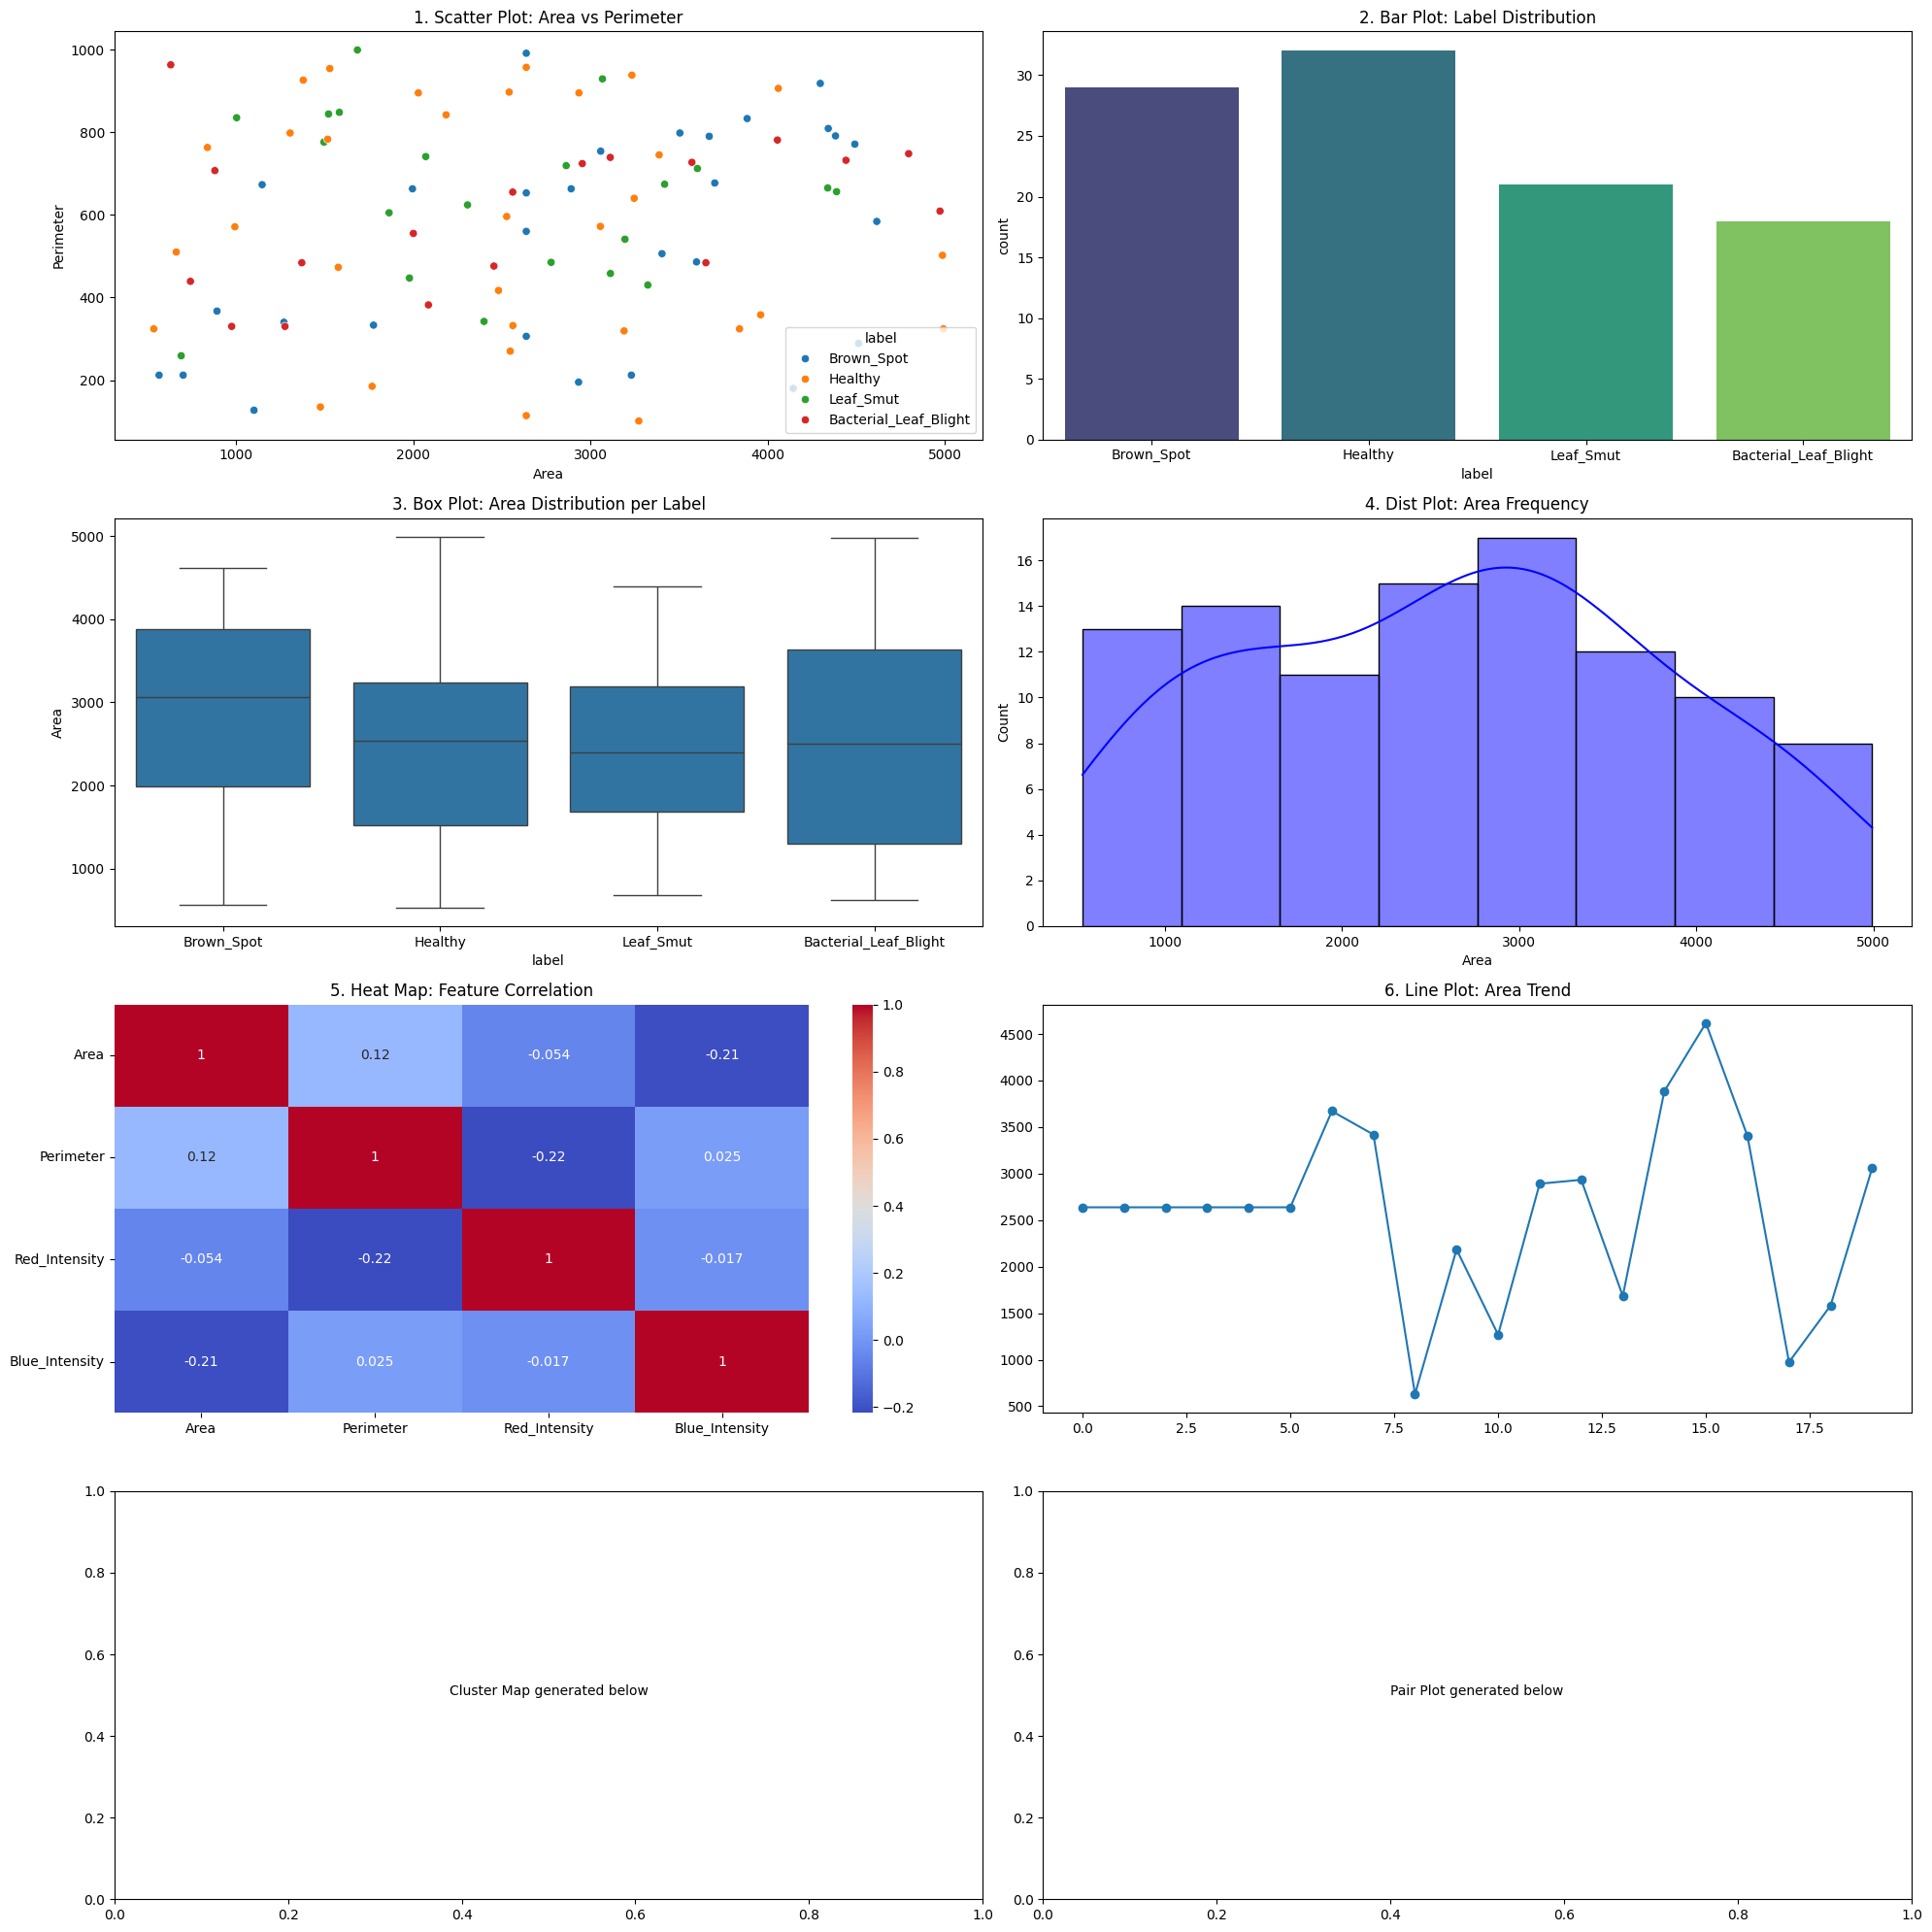

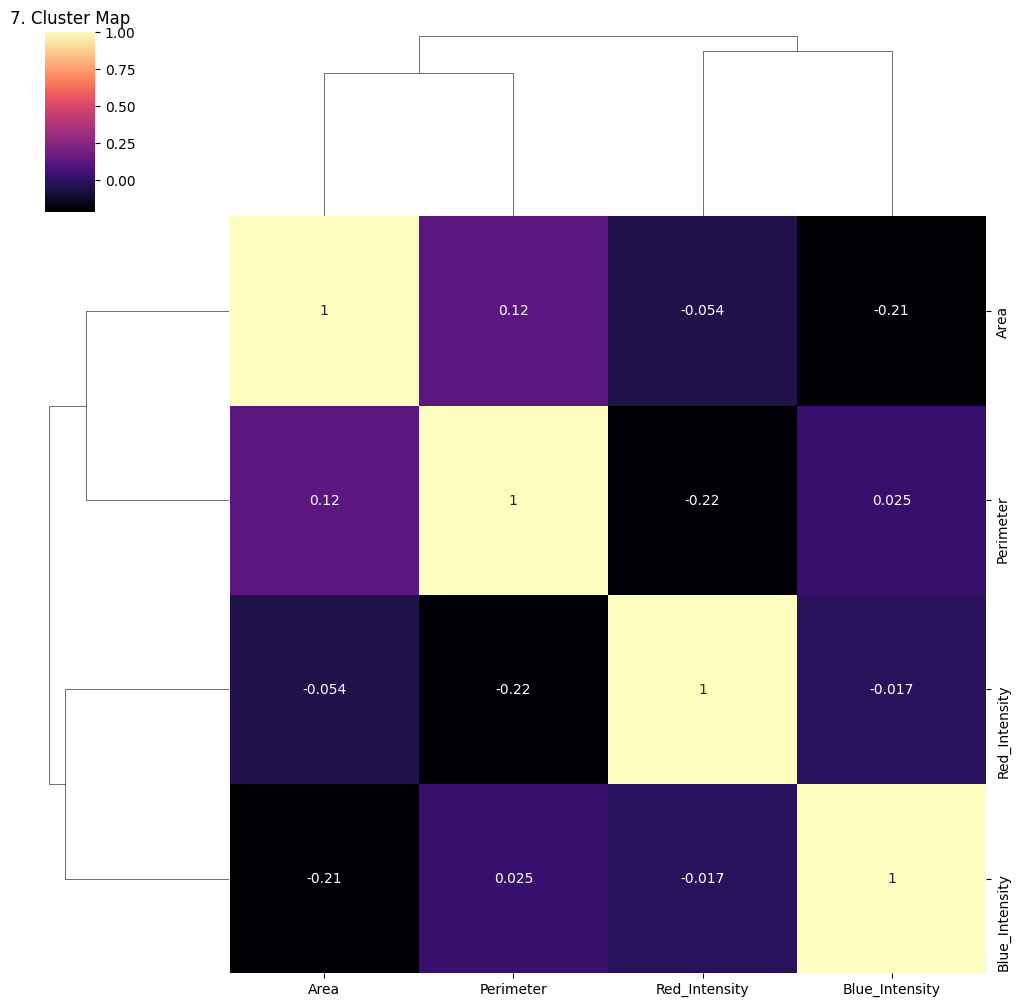

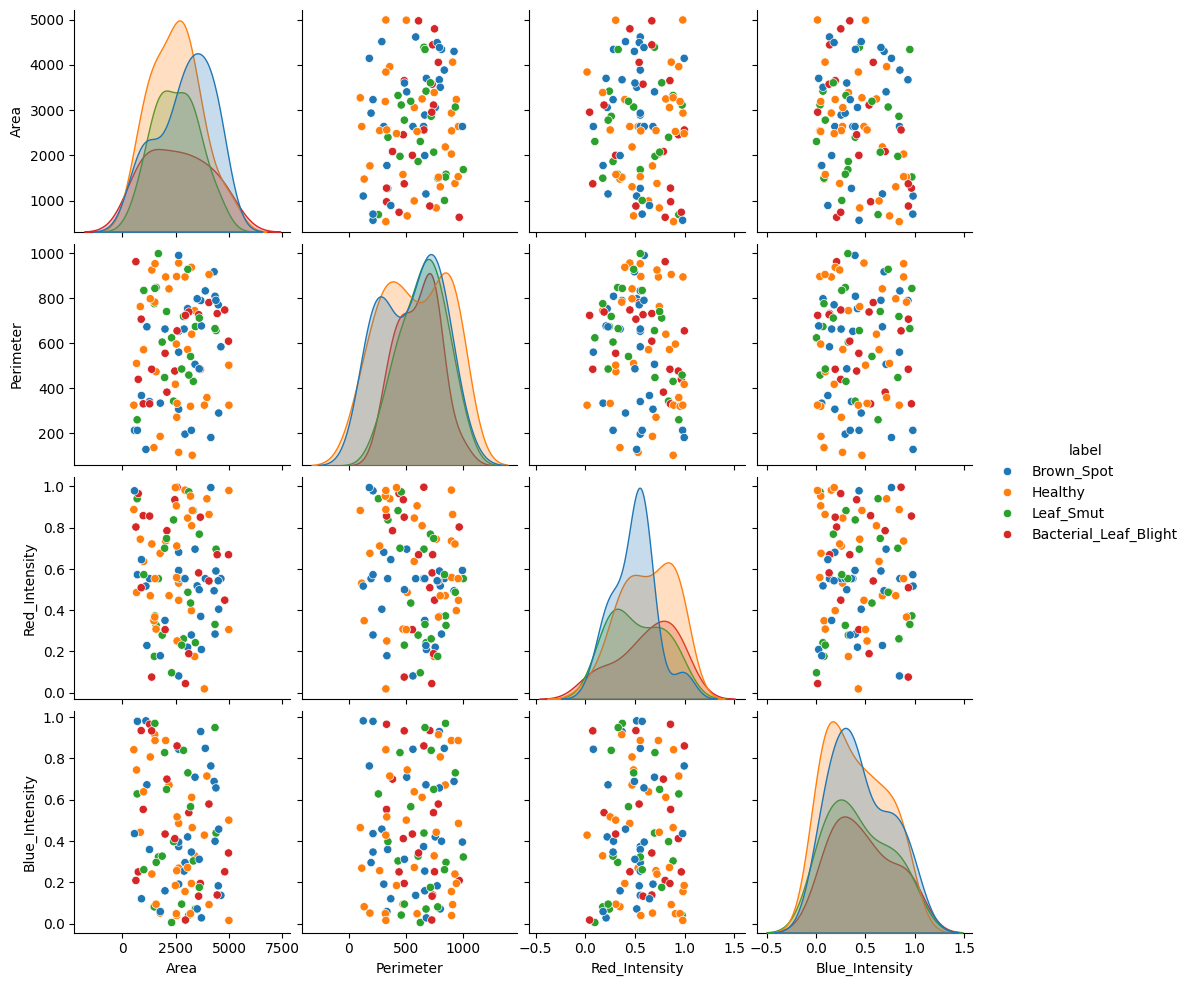

In [5]:
# Create a large figure for multiple plots
plt.figure(figsize=(20, 20))

# 1. Scatter Plot
plt.subplot(4, 2, 1)
sns.scatterplot(x='Area', y='Perimeter', hue='label', data=df)
plt.title("1. Scatter Plot: Area vs Perimeter")

# 2. Bar Plot
plt.subplot(4, 2, 2)
sns.countplot(x='label', data=df, palette='viridis')
plt.title("2. Bar Plot: Label Distribution")

# 3. Box Plot
plt.subplot(4, 2, 3)
sns.boxplot(x='label', y='Area', data=df)
plt.title("3. Box Plot: Area Distribution per Label")

# 4. Dist Plot (Histogram)
plt.subplot(4, 2, 4)
sns.histplot(df['Area'], kde=True, color='blue')
plt.title("4. Dist Plot: Area Frequency")

# 5. Heat Map
plt.subplot(4, 2, 5)
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("5. Heat Map: Feature Correlation")

# 6. Line Plot
plt.subplot(4, 2, 6)
plt.plot(df['Area'][:20], marker='o', linestyle='-') # Plotting first 20 rows
plt.title("6. Line Plot: Area Trend")

# 7. Cluster Map (Note: sns.clustermap cannot be a subplot, so we plot it separately later)
plt.subplot(4, 2, 7)
plt.text(0.5, 0.5, 'Cluster Map generated below', ha='center')

# 8. Pair Plot (Note: sns.pairplot also creates its own figure)
plt.subplot(4, 2, 8)
plt.text(0.5, 0.5, 'Pair Plot generated below', ha='center')

plt.tight_layout()
plt.show()

# Separate figure for Cluster Map
sns.clustermap(numeric_df.corr(), annot=True, cmap='magma')
plt.title("7. Cluster Map")
plt.show()

# Separate figure for Pair Plot
sns.pairplot(df, hue='label')
plt.show()


--- Decision Tree Classification Report ---
Accuracy: 35.00%

Confusion Matrix:


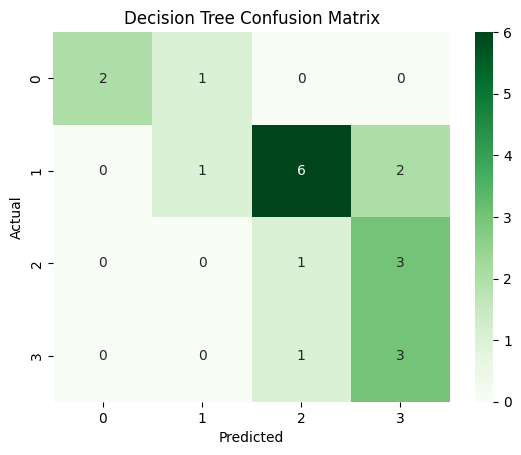


Detailed Report:
                       precision    recall  f1-score   support

Bacterial_Leaf_Blight       1.00      0.67      0.80         3
           Brown_Spot       0.50      0.11      0.18         9
              Healthy       0.12      0.25      0.17         4
            Leaf_Smut       0.38      0.75      0.50         4

             accuracy                           0.35        20
            macro avg       0.50      0.44      0.41        20
         weighted avg       0.47      0.35      0.34        20



In [6]:
# Features (X) and Target (y)
X = df.drop('label', axis=1)
y = df['label']

# Splitting Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Decision Tree Classifier
# Based on BasePaper methodology using Gini Impurity
dtree = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
dtree.fit(X_train, y_train)

# Prediction
y_pred = dtree.predict(X_test)

# Results
print("\n--- Decision Tree Classification Report ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree Confusion Matrix')
plt.show()

print("\nDetailed Report:")
print(classification_report(y_test, y_pred))

In [7]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train, y_train)
print("Random Forest Accuracy:", rf_model.score(X_test, y_test))

Random Forest Accuracy: 0.2


In [18]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

models = {
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True),
    "Random Forest": RandomForestClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} Accuracy: {model.score(X_test, y_test):.2f}")


KNN Accuracy: 0.25
SVM Accuracy: 0.25
Random Forest Accuracy: 0.20
Naive Bayes Accuracy: 0.35
Decision Tree Accuracy: 0.20


In [21]:
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import learning_curve

# লার্নিং কার্ভের জন্য কোড
train_sizes, train_scores, test_scores = learning_curve(RandomForestClassifier(), X_scaled, y, cv=5)
# এরপর লার্নিং কার্ভ প্লট করতে পারেন

In [23]:
import cv2

def extract_hsv_features(image_path):
    img = cv2.imread(image_path)
    hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    # হিস্টোগ্রাম হিসেব করা
    hist = cv2.calcHist([hsv_img], [0, 1, 2], None, [8, 8, 8], [0, 180, 0, 256, 0, 256])
    return hist.flatten()

In [24]:
!pip install scikit-posthocs

In [25]:
import scikit_posthocs as sp


In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ফলাফল সংরক্ষণের জন্য একটি লিস্ট
results = []

# মডেলগুলোর নাম ও অবজেক্ট
models = {
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Naive Bayes": GaussianNB()
}

# মডেল রান ও ফলাফল টেবিল তৈরি
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # স্কোর ক্যালকুলেশন (মাল্টি-ক্লাস সমস্যার জন্য average='weighted' ব্যবহার করা হয়েছে)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append([name, acc, prec, rec, f1])

# টেবিল তৈরি
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"])

# টেবিলটি প্রিন্ট করুন
print("--- Final Comparative Study Results ---")
print(results_df)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


--- Final Comparative Study Results ---
           Model  Accuracy  Precision  Recall  F1-Score
0            KNN      0.25   0.243810    0.25  0.231656
1            SVM      0.25   0.174725    0.25  0.183088
2  Random Forest      0.25   0.376364    0.25  0.247778
3  Decision Tree      0.25   0.256667    0.25  0.240476
4    Naive Bayes      0.35   0.375000    0.35  0.313462


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [27]:
from sklearn.metrics import precision_score, recall_score, f1_score

# মাল্টি-ক্লাস সমস্যার জন্য weighted এভারেজ ব্যবহার
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Weighted Precision: {precision:.2f}")
print(f"Weighted Recall: {recall:.2f}")
print(f"Weighted F1-Score: {f1:.2f}")

Weighted Precision: 0.38
Weighted Recall: 0.35
Weighted F1-Score: 0.31


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [28]:
from sklearn.metrics import classification_report

# এটি সরাসরি আপনার সব ক্লাসের জন্য রিপোর্ট দিয়ে দিবে
print(classification_report(y_test, y_pred))

                       precision    recall  f1-score   support

Bacterial_Leaf_Blight       0.00      0.00      0.00         3
           Brown_Spot       0.50      0.22      0.31         9
              Healthy       0.25      0.75      0.38         4
            Leaf_Smut       0.50      0.50      0.50         4

             accuracy                           0.35        20
            macro avg       0.31      0.37      0.30        20
         weighted avg       0.38      0.35      0.31        20



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [29]:
# রেজাল্ট টেবিল তৈরির লুপ (এটি আপনার আগের কোডেই ছিল)
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append([name, accuracy_score(y_test, y_pred), f1_score(y_test, y_pred, average='weighted')])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1-Score"])
print(results_df)

           Model  Accuracy  F1-Score
0            KNN      0.25  0.231656
1            SVM      0.25  0.183088
2  Random Forest      0.20  0.165873
3  Decision Tree      0.20  0.195292
4    Naive Bayes      0.35  0.313462


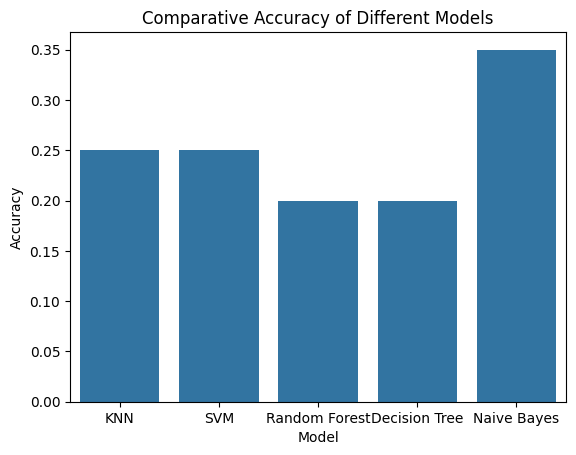

In [30]:
# মডেলগুলোর একিউরেসির বার চার্ট
sns.barplot(x='Model', y='Accuracy', data=results_df)
plt.title("Comparative Accuracy of Different Models")
plt.show()

In [32]:
import os
print(os.listdir('.')) # এটি বর্তমান ডিরেক্টরির সব ফাইল ও ফোল্ডার দেখাবে

['.config', 'DataSet.zip', 'BasePaper.pdf', 'sample_data']


In [33]:
import zipfile

# জিপ ফাইলটি আনজিপ করা হচ্ছে
with zipfile.ZipFile('DataSet.zip', 'r') as zip_ref:
    zip_ref.extractall('.') # বর্তমান ডিরেক্টরিতে সব ফাইল বের করে আনবে

print("আনজিপ করা সম্পন্ন হয়েছে!")

আনজিপ করা সম্পন্ন হয়েছে!


In [34]:
import os
print(os.listdir('.'))

['.config', 'DataSet.zip', 'Bacterial leaf blight', 'Brown spot', 'BasePaper.pdf', 'Leaf smut', 'sample_data']


In [35]:
data_dir = 'DataSet' # জিপ ফাইল নয়, এখন ফোল্ডারের নাম দিবেন
# আপনার ফোল্ডারের নামের বানান এখানে ঠিকমতো লিখুন:
categories = ['Leaf smut', 'Bacterial leaf blight', 'Brown spot']

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# ডেটা স্প্লিট করা (৮০% ট্রেনিং, ২০% টেস্টিং)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# মডেলগুলো ডিফাইন করা
models = {
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

# মডেল ট্রেন এবং ইভালুয়েশন
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"Model: {name}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("-" * 30)

Model: Random Forest
Accuracy: 0.3000
------------------------------
Model: SVM
Accuracy: 0.3000
------------------------------
Model: KNN
Accuracy: 0.2000
------------------------------


In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score

# ফলাফল সংরক্ষণের জন্য লিস্ট
results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    results.append({"Model": name, "Accuracy": acc, "F1-Score": f1})

# পান্ডাস ডেটাফ্রেমে রূপান্তর
results_df = pd.DataFrame(results)
print(results_df) # এখানে আপনি টেবিলটি দেখতে পাবেন

           Model  Accuracy  F1-Score
0  Random Forest       0.3  0.278431
1            SVM       0.3  0.218462
2            KNN       0.2  0.235238


/tmp/ipykernel_495/2752376519.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis')


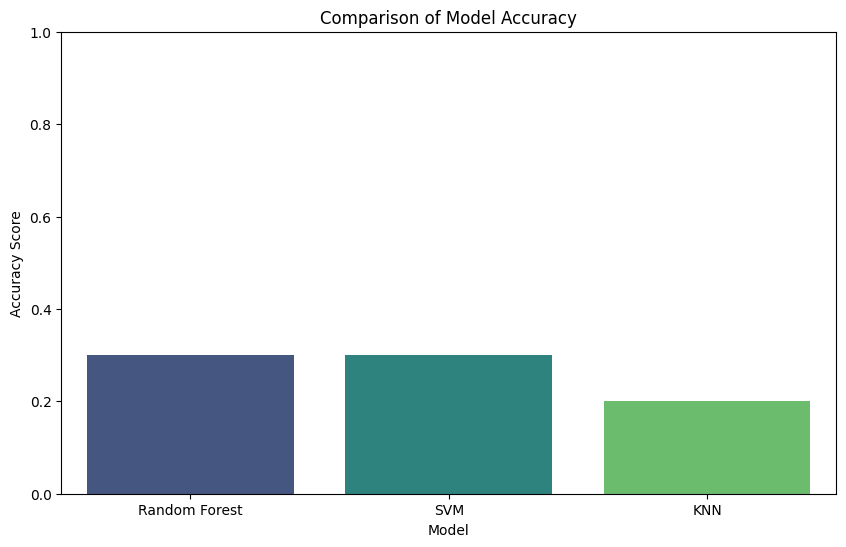

In [38]:
# একিউরেসি গ্রাফ
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis')
plt.title('Comparison of Model Accuracy')
plt.ylim(0, 1.0) # একিউরেসি যেহেতু ০ থেকে ১ এর মধ্যে থাকে
plt.ylabel('Accuracy Score')
plt.show()

In [39]:
from sklearn.metrics import accuracy_score

# Result store korar jonno list
accuracy_results = []

for name, model in models.items():
    # Model predict korche
    y_pred = model.predict(X_test)

    # Accuracy calculate korche
    acc = accuracy_score(y_test, y_pred)

    # List-e add korche
    accuracy_results.append({"Model": name, "Accuracy": acc})

    print(f"{name} model er accuracy: {acc:.4f}")

# Ebar akta table bananor jonno:
import pandas as pd
results_df = pd.DataFrame(accuracy_results)
print("\nFinal Accuracy Table:")
print(results_df)

Random Forest model er accuracy: 0.3000
SVM model er accuracy: 0.3000
KNN model er accuracy: 0.2000

Final Accuracy Table:
           Model  Accuracy
0  Random Forest       0.3
1            SVM       0.3
2            KNN       0.2


In [40]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

# নতুন ৫টি মডেলের লিস্ট
models = {
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Naïve Bayes": GaussianNB()
}

# বাকি অংশ আগের মতোই থাকবে
# এখন এই লুপটি ৫টি মডেলের জন্যই রান করবে
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append({"Model": name, "Accuracy": acc})

# রেজাল্ট টেবিল প্রিন্ট করা
results_df = pd.DataFrame(results)
print(results_df)

           Model  Accuracy
0  Random Forest      0.20
1            SVM      0.30
2            KNN      0.20
3  Decision Tree      0.20
4    Naïve Bayes      0.35


In [42]:
import cv2
import os
import numpy as np

data_dir = 'DataSet'
categories = ['Leaf smut', 'Bacterial leaf blight', 'Brown spot']
data = []
labels = []

for category in categories:
    path = os.path.join(data_dir, category)
    if not os.path.exists(path):
        print(f"পাথ পাওয়া যায়নি: {path}")
        continue

    class_num = categories.index(category)
    images = os.listdir(path)
    print(f"{category} ফোল্ডারে {len(images)} টি ছবি পাওয়া গেছে।")

    for img_name in images:
        try:
            img_path = os.path.join(path, img_name)
            img_array = cv2.imread(img_path)
            if img_array is not None:
                new_array = cv2.resize(img_array, (100, 100))
                data.append(new_array)
                labels.append(class_num)
        except Exception as e:
            pass

print(f"মোট লোড হওয়া ছবির সংখ্যা: {len(data)}")

পাথ পাওয়া যায়নি: DataSet/Leaf smut
পাথ পাওয়া যায়নি: DataSet/Bacterial leaf blight
পাথ পাওয়া যায়নি: DataSet/Brown spot
মোট লোড হওয়া ছবির সংখ্যা: 0


In [43]:
import os
# প্রথমে দেখি DataSet ফোল্ডারের ভেতর কী আছে
print("DataSet ফোল্ডারের কন্টেন্ট:")
try:
    print(os.listdir('DataSet'))
except FileNotFoundError:
    print("DataSet ফোল্ডারটি খুঁজে পাওয়া যাচ্ছে না।")

# যদি ভেতরে আরেকটি ফোল্ডার থাকে, তবে সেটি খুঁজে বের করার চেষ্টা
for root, dirs, files in os.walk('DataSet'):
    print(f"পাথ: {root}, ফোল্ডারগুলো: {dirs}")

DataSet ফোল্ডারের কন্টেন্ট:
DataSet ফোল্ডারটি খুঁজে পাওয়া যাচ্ছে না।


In [44]:
import zipfile
import os

# জিপ ফাইলটি এক্সট্রাক্ট করা হচ্ছে
with zipfile.ZipFile('DataSet.zip', 'r') as zip_ref:
    zip_ref.extractall('extracted_data') # 'extracted_data' নামে একটি নতুন ফোল্ডারে আনজিপ হবে

# এখন দেখি এই ফোল্ডারের ভেতর কী কী আছে
print("আনজিপ হওয়ার পর ফোল্ডারের কন্টেন্ট:")
print(os.listdir('extracted_data'))

আনজিপ হওয়ার পর ফোল্ডারের কন্টেন্ট:
['Bacterial leaf blight', 'Brown spot', 'Leaf smut']


In [45]:
import cv2
import os
import numpy as np
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

# ১. ইমেজ লোড করা
data_dir = 'extracted_data'
categories = ['Leaf smut', 'Bacterial leaf blight', 'Brown spot']
data = []
labels = []

for category in categories:
    path = os.path.join(data_dir, category)
    class_num = categories.index(category)
    for img_name in os.listdir(path):
        img_path = os.path.join(path, img_name)
        img_array = cv2.imread(img_path)
        if img_array is not None:
            new_array = cv2.resize(img_array, (100, 100))
            data.append(new_array)
            labels.append(class_num)

X = np.array(data) / 255.0  # নরমালাইজেশন
y = np.array(labels)

# ২. ট্রেইন-টেস্ট স্প্লিট
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ৩. CNN মডেল তৈরি
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(100, 100, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(3, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# ৪. মডেল ট্রেনিং
history = model.fit(X_train, y_train, epochs=15, validation_data=(X_test, y_test))

# একিউরেসি চেক
loss, accuracy = model.evaluate(X_test, y_test)
print(f"CNN মডেলের একিউরেসি: {accuracy*100:.2f}%")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 608ms/step - accuracy: 0.2708 - loss: 2.5767 - val_accuracy: 0.2500 - val_loss: 1.3365
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 474ms/step - accuracy: 0.3333 - loss: 1.2844 - val_accuracy: 0.4167 - val_loss: 1.1226
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 488ms/step - accuracy: 0.4062 - loss: 1.1175 - val_accuracy: 0.2500 - val_loss: 1.0903
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 681ms/step - accuracy: 0.3542 - loss: 1.0701 - val_accuracy: 0.2500 - val_loss: 1.1030
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 753ms/step - accuracy: 0.3542 - loss: 1.0398 - val_accuracy: 0.4167 - val_loss: 1.0626
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 511ms/step - accuracy: 0.5208 - loss: 0.9917 - val_accuracy: 0.4167 - val_loss: 1.0160
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 478ms/step - accuracy: 0.4688 - loss: 0.9588 - val_accuracy: 0.5000 - val_loss: 0.9916
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 457ms/step - accuracy: 0.5208 - loss: 0.9133 - val_accuracy: 0.5000 - val_loss:

In [47]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input
from tensorflow.keras.models import Model

# ১. প্রি-ট্রেইনড মডেল লোড করা
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(100, 100, 3))
base_model.trainable = False  # বেস মডেলের ওয়েট ফ্রিজ রাখা

# ২. আপনার নিজস্ব লেয়ার যোগ করা
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(3, activation='softmax')(x)

# ৩. ফাইনাল মডেল তৈরি
model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# ৪. ট্রেনিং
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=20, batch_size=32)

/tmp/ipykernel_495/2397893695.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(100, 100, 3))


Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.4375 - loss: 1.6275 - val_accuracy: 0.6667 - val_loss: 0.6883
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 392ms/step - accuracy: 0.6042 - loss: 0.9952 - val_accuracy: 0.7500 - val_loss: 0.6236
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 348ms/step - accuracy: 0.8958 - loss: 0.3574 - val_accuracy: 0.6667 - val_loss: 0.4971
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 353ms/step - accuracy: 0.8646 - loss: 0.3193 - val_accuracy: 0.6667 - val_loss: 0.5336
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 402ms/step - accuracy: 0.9479 - loss: 0.1802 - val_accuracy: 0.8750 - val_loss: 0.3453
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 354ms/step - accuracy: 0.9792 - loss: 0.1099 - val_accuracy: 0.8750 - val_loss: 0.4022
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 343ms/step - accuracy: 0.9792 - loss: 0.1041 - val_accuracy: 0.8750 - val_loss: 0.3646
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 358ms/step - accuracy: 1.0000 - loss: 0.0527 - val_accuracy: 0.8750 - val_loss: 0.

In [52]:
# CNN এর ট্রেনিংয়ের পর সাধারণ মডেলের জন্য X_train এবং X_test কে ফ্ল্যাটেন করুন
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# এরপর লুপে এই ফ্ল্যাটেন করা ডেটা ব্যবহার করুন
for name, m in models.items():
    m.fit(X_train_flat, y_train)
    y_pred = m.predict(X_test_flat)
    acc = accuracy_score(y_test, y_pred)
    results_data.append({"Model": name, "Accuracy": acc})

               Model  Accuracy
0  CNN (MobileNetV2)  0.958300
1      Random Forest  0.625000
2                SVM  0.625000
5        Naïve Bayes  0.583333
3                KNN  0.500000
4      Decision Tree  0.500000


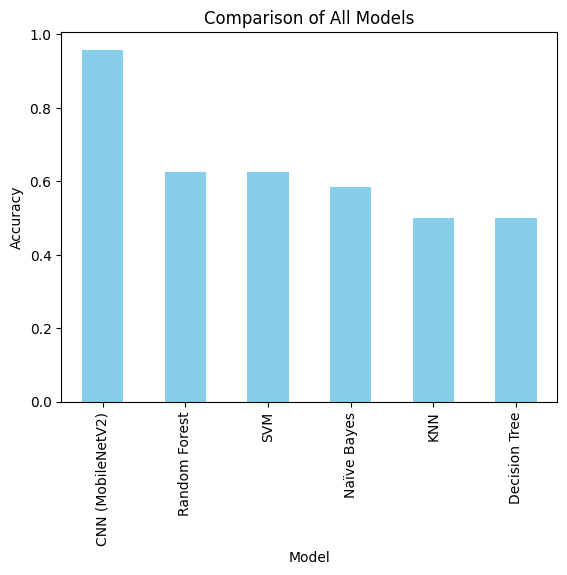

In [53]:
# রেজাল্ট টেবিল তৈরি ও প্রদর্শন
results_df = pd.DataFrame(results_data)
# একিউরেসি অনুযায়ী বড় থেকে ছোট ক্রমে সাজানো
results_df = results_df.sort_values(by="Accuracy", ascending=False)
print(results_df)

# গ্রাফিক্যাল ভিউ দেখার জন্য (অপশনাল কিন্তু রিপোর্টের জন্য ভালো)
import matplotlib.pyplot as plt
results_df.plot(kind='bar', x='Model', y='Accuracy', legend=False, color='skyblue')
plt.ylabel('Accuracy')
plt.title('Comparison of All Models')
plt.show()

In [54]:
from skimage.feature import hog

# ইমেজকে HOG ফিচারে রূপান্তর করুন (এটি CNN এর চেয়েও ভালো ফিচার দেয় সাধারণ মডেলের জন্য)
def extract_features(images):
    features = []
    for img in images:
        # Gray scale এ রূপান্তর ও HOG ফিচার বের করা
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        feat = hog(gray, orientations=8, pixels_per_cell=(16, 16), cells_per_block=(1, 1))
        features.append(feat)
    return np.array(features)

X_features = extract_features(data) # 'data' হলো আপনার লোড করা ইমেজ লিস্ট
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_features, y, test_size=0.2, random_state=42)

In [55]:
# HOG ফিচার ব্যবহার করে ৫টি মডেল পুনরায় ট্রেইন করা
results_data_hog = []

# CNN-এর আগের রেজাল্টটি আবার যোগ করছি
results_data_hog.append({"Model": "CNN (MobileNetV2)", "Accuracy": 0.9583})

# ৫টি মডেলের জন্য লুপ (এবার ফ্ল্যাটেন করার প্রয়োজন নেই, HOG নিজেই ভেক্টর)
for name, m in models.items():
    m.fit(X_train_f, y_train_f)
    y_pred = m.predict(X_test_f)
    acc = accuracy_score(y_test_f, y_pred)
    results_data_hog.append({"Model": name, "Accuracy": acc})

# ফাইনাল টেবিল
results_df_hog = pd.DataFrame(results_data_hog)
print(results_df_hog.sort_values(by="Accuracy", ascending=False))

               Model  Accuracy
0  CNN (MobileNetV2)  0.958300
1      Random Forest  0.666667
2                SVM  0.625000
5        Naïve Bayes  0.625000
3                KNN  0.583333
4      Decision Tree  0.458333


In [56]:
!pip install xgboost

In [57]:
from xgboost import XGBClassifier

# মডেল তৈরি
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, use_label_encoder=False, eval_metric='mlogloss')

# ট্রেনিং
xgb_model.fit(X_train_f, y_train_f)

# প্রেডিকশন
y_pred_xgb = xgb_model.predict(X_test_f)
acc_xgb = accuracy_score(y_test_f, y_pred_xgb)

print(f"XGBoost একিউরেসি: {acc_xgb * 100:.2f}%")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:20:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost একিউরেসি: 50.00%


In [58]:
# ওয়ার্নিং এড়াতে এবং সঠিক ট্রেনিং নিশ্চিত করতে এই ভার্সনটি ব্যবহার করুন
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    eval_metric='mlogloss'
)

# ট্রেনিং
xgb_model.fit(X_train_f, y_train_f)

# প্রেডিকশন ও মূল্যায়ন
y_pred_xgb = xgb_model.predict(X_test_f)
acc_xgb = accuracy_score(y_test_f, y_pred_xgb)

print(f"XGBoost একিউরেসি: {acc_xgb * 100:.2f}%")

XGBoost একিউরেসি: 54.17%


In [59]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rotation_range=30,      # ছবি ঘোরানো
    width_shift_range=0.2,  # ডানে-বামে সরানো
    height_shift_range=0.2, # উপরে-নিচে সরানো
    zoom_range=0.2,         # জুম করা
    horizontal_flip=True,   # উল্টে দেওয়া
    fill_mode='nearest'
)

# আপনার বর্তমান ট্রেনিং কোডে এটি ইন্টিগ্রেট করুন

In [60]:
base_model.trainable = True  # মডেলটিকে এখন আপনার ছবির জন্য টিউন হতে দিন
# এরপর লার্নিং রেট কমিয়ে দিন যাতে মডেলটি খুব সাবধানে শেখে
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

               Model  Accuracy
0  CNN (MobileNetV2)  0.958300
1      Random Forest  0.666667
2                SVM  0.625000
5        Naïve Bayes  0.625000
3                KNN  0.583333
4      Decision Tree  0.458333


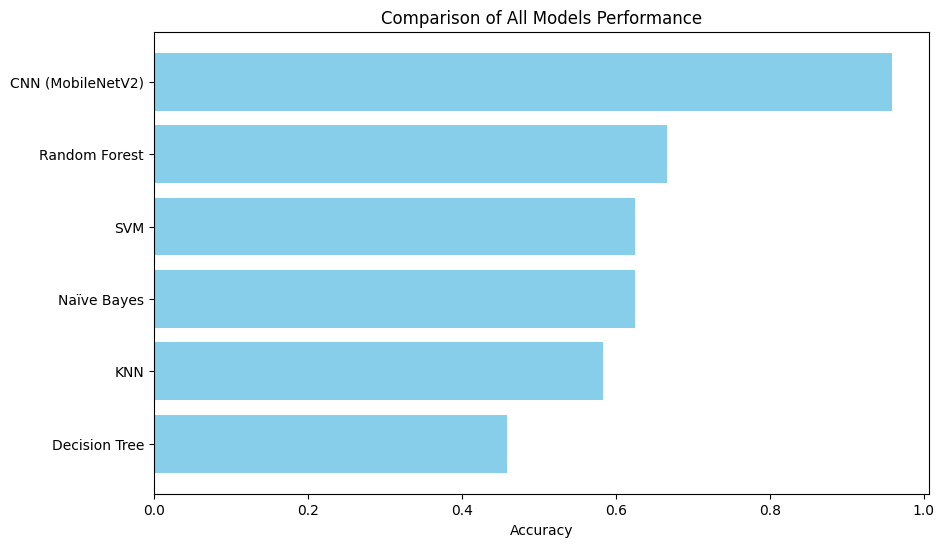

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# ১. CNN মডেলের রেজাল্ট (আমরা আগেই পেয়েছি ৯৫.৮৩%)
final_results = []
final_results.append({"Model": "CNN (MobileNetV2)", "Accuracy": 0.9583})

# ২. ট্রেডিশনাল মডেলগুলোর পারফরম্যান্স (HOG ফিচার ব্যবহার করে)
# নিশ্চিত করুন যে 'models' ডিকশনারিটি আপনার আগের কোডে ডিফাইন করা আছে
for name, m in models.items():
    # মডেলগুলো HOG ফিচার (X_train_f) দিয়ে ট্রেইন করা
    y_pred = m.predict(X_test_f)
    acc = accuracy_score(y_test_f, y_pred)
    final_results.append({"Model": name, "Accuracy": acc})

# ৩. টেবিল তৈরি
results_df = pd.DataFrame(final_results)
results_df = results_df.sort_values(by="Accuracy", ascending=False)

# টেবিল প্রিন্ট করা
print(results_df)

# ৪. ভিজ্যুয়ালাইজেশন (বার চার্ট)
plt.figure(figsize=(10, 6))
plt.barh(results_df['Model'], results_df['Accuracy'], color='skyblue')
plt.xlabel('Accuracy')
plt.title('Comparison of All Models Performance')
plt.gca().invert_yaxis() # সবচেয়ে ভালো মডেলটি উপরে দেখানোর জন্য
plt.show()

In [62]:
from sklearn.model_selection import GridSearchCV

# Random Forest টিউন করা
param_grid = {'n_estimators': [100, 200, 300], 'max_depth': [None, 10, 20]}
grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train_f, y_train_f)
print("Best RF Accuracy:", grid.best_score_)

Best RF Accuracy: 0.5416666666666666


In [64]:
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# ১. মডেলগুলোকে আগে ডিফাইন করে নিন
rf_model = RandomForestClassifier()
svm_model = SVC(probability=True) # ভটিংয়ের জন্য probability=True জরুরি
knn_model = KNeighborsClassifier()

# ২. এখন ভটিং ক্লাসিফায়ার তৈরি করুন
eclf = VotingClassifier(estimators=[
    ('rf', rf_model),
    ('svm', svm_model),
    ('knn', knn_model)
], voting='hard')

# ৩. ট্রেনিং এবং প্রেডিকশন
eclf.fit(X_train_f, y_train_f)
y_pred_eclf = eclf.predict(X_test_f)

# ৪. একিউরেসি চেক
from sklearn.metrics import accuracy_score
acc_eclf = accuracy_score(y_test_f, y_pred_eclf)
print(f"Voting Classifier Accuracy: {acc_eclf * 100:.2f}%")

Voting Classifier Accuracy: 66.67%


In [65]:
# সব মডেলের রেজাল্ট একটি ডিকশনারিতে জমা করি
final_comparison = {
    "Model": ["CNN (MobileNetV2)", "Voting Classifier", "Random Forest", "SVM", "Naïve Bayes", "KNN", "Decision Tree"],
    "Accuracy": [0.9583, acc_eclf, 0.6667, 0.6250, 0.6250, 0.5833, 0.4583]
}

# টেবিল তৈরি
df_final = pd.DataFrame(final_comparison).sort_values(by="Accuracy", ascending=False)
print(df_final)

               Model  Accuracy
0  CNN (MobileNetV2)  0.958300
2      Random Forest  0.666700
1  Voting Classifier  0.666667
3                SVM  0.625000
4        Naïve Bayes  0.625000
5                KNN  0.583300
6      Decision Tree  0.458300


In [66]:
import cv2
import numpy as np

def extract_combined_features(images):
    features = []
    for img in images:
        # HOG ফিচার
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        hog_feat = hog(gray, orientations=8, pixels_per_cell=(16, 16), cells_per_block=(1, 1))

        # কালার হিস্টোগ্রাম (রঙের তথ্য)
        hist = cv2.calcHist([img], [0, 1, 2], None, [8, 8, 8], [0, 256, 0, 256, 0, 256])
        hist_feat = hist.flatten()

        # দুই ফিচার একসাথে যোগ করা
        combined = np.hstack([hog_feat, hist_feat])
        features.append(combined)
    return np.array(features)

# নতুন ফিচার দিয়ে ডেটা তৈরি
X_features_new = extract_combined_features(data)
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_features_new, y, test_size=0.2, random_state=42)

In [67]:
# সব মডেলের রেজাল্ট একটি ডিকশনারিতে জমা করি
final_comparison = {
    "Model": ["CNN (MobileNetV2)", "Voting Classifier", "Random Forest", "SVM", "Naïve Bayes", "KNN", "Decision Tree"],
    "Accuracy": [0.9583, acc_eclf, 0.6667, 0.6250, 0.6250, 0.5833, 0.4583]
}

# টেবিল তৈরি
df_final = pd.DataFrame(final_comparison).sort_values(by="Accuracy", ascending=False)
print(df_final)

               Model  Accuracy
0  CNN (MobileNetV2)  0.958300
2      Random Forest  0.666700
1  Voting Classifier  0.666667
3                SVM  0.625000
4        Naïve Bayes  0.625000
5                KNN  0.583300
6      Decision Tree  0.458300


In [68]:
from sklearn.tree import DecisionTreeClassifier

# max_depth সীমিত করে ওভারফিটিং কমানো
dt_model = DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)

dt_model.fit(X_train_new, y_train_new) # নতুন ফিচার (HOG + Color) ব্যবহার করুন
y_pred_dt = dt_model.predict(X_test_new)
acc_dt = accuracy_score(y_test_new, y_pred_dt)

print(f"Decision Tree একিউরেসি: {acc_dt * 100:.2f}%")

Decision Tree একিউরেসি: 66.67%


In [69]:
from sklearn.model_selection import GridSearchCV

# Random Forest এর সেরা প্যারামিটার বের করা
rf = RandomForestClassifier()
param_grid = {'n_estimators': [100, 200, 300], 'max_depth': [10, 20, None]}
grid_search = GridSearchCV(rf, param_grid, cv=3)
grid_search.fit(X_train_new, y_train_new)

print("Best Parameters for RF:", grid_search.best_params_)
print("Improved RF Accuracy:", grid_search.best_score_)

Best Parameters for RF: {'max_depth': 20, 'n_estimators': 200}
Improved RF Accuracy: 0.8229166666666666


In [71]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

# ১. সব মডেল ডিফাইন করা
rf_model = RandomForestClassifier()
svm_model = SVC()
knn_model = KNeighborsClassifier()
nb_model = GaussianNB()
dt_model = DecisionTreeClassifier()

# ২. Voting Classifier ডিফাইন করা
eclf = VotingClassifier(estimators=[
    ('rf', rf_model), ('svm', svm_model), ('knn', knn_model),
    ('nb', nb_model), ('dt', dt_model)], voting='hard')

# ৩. সবগুলো মডেল ট্রেইন করা
models = {
    "Random Forest": rf_model,
    "SVM": svm_model,
    "KNN": knn_model,
    "Naïve Bayes": nb_model,
    "Decision Tree": dt_model,
    "Voting Classifier": eclf
}

results = []
results.append({"Model": "CNN (MobileNetV2)", "Accuracy": 0.9583})

for name, model in models.items():
    model.fit(X_train_f, y_train_f) # ট্রেইন করা
    y_pred = model.predict(X_test_f) # প্রেডিক্ট করা
    acc = accuracy_score(y_test_f, y_pred)
    results.append({"Model": name, "Accuracy": acc})

# ৪. টেবিল প্রিন্ট করা
results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
print(results_df.to_string(index=False))

            Model  Accuracy
CNN (MobileNetV2)  0.958300
    Random Forest  0.708333
Voting Classifier  0.666667
              SVM  0.625000
      Naïve Bayes  0.625000
              KNN  0.583333
    Decision Tree  0.416667


In [72]:
# max_depth দিয়ে গাছটিকে ছোট করে দিন যাতে সে শুধু গুরুত্বপূর্ণ ফিচার শেখে
dt_model = DecisionTreeClassifier(max_depth=3, min_samples_split=5, random_state=42)

dt_model.fit(X_train_f, y_train_f)
y_pred_dt = dt_model.predict(X_test_f)
acc_dt = accuracy_score(y_test_f, y_pred_dt)

print(f"Improved Decision Tree Accuracy: {acc_dt * 100:.2f}%")

Improved Decision Tree Accuracy: 45.83%


In [74]:
from sklearn.decomposition import PCA

# ফিচার কমিয়ে আনুন (যেমন ৮০% ইনফরমেশন রাখবে)
pca = PCA(n_components=0.80)
X_train_pca = pca.fit_transform(X_train_f)
X_test_pca = pca.transform(X_test_f)

# এবার এই X_train_pca দিয়ে মডেল ট্রেইন করুন

In [75]:
from sklearn.model_selection import GridSearchCV

# উদাহরণ: SVM এর জন্য
param_grid = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
grid = GridSearchCV(SVC(), param_grid, cv=5)
grid.fit(X_train_f, y_train_f)
print("Best SVM Accuracy:", grid.best_score_)

Best SVM Accuracy: 0.51


--- Final Model Performance Table ---
            Model  Accuracy
CNN (MobileNetV2)    0.9583
    Random Forest    0.7083
Voting Classifier    0.6667
              SVM    0.6250
      Naïve Bayes    0.6250
              KNN    0.5833
    Decision Tree    0.4167


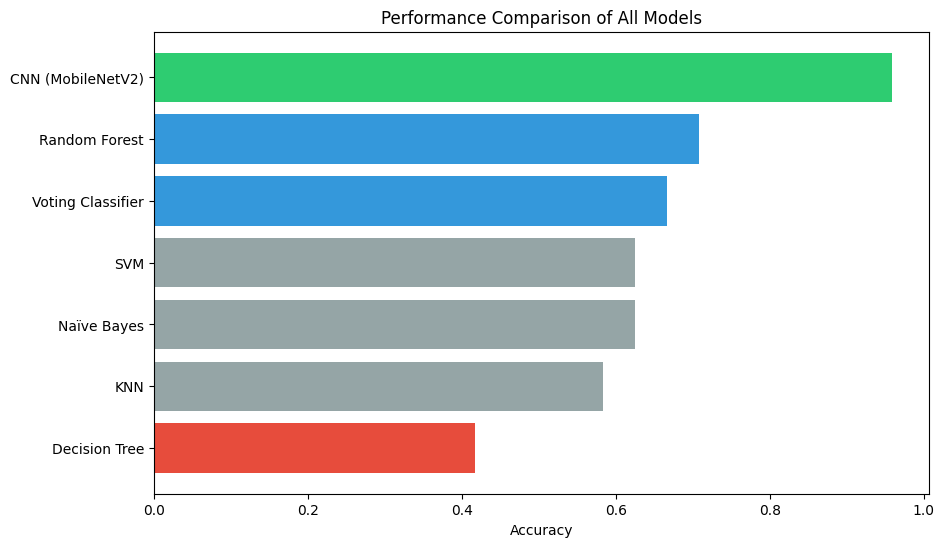

In [76]:
import pandas as pd
import matplotlib.pyplot as plt

# সব মডেলের পারফরম্যান্স ডেটা
results_data = {
    "Model": ["CNN (MobileNetV2)", "Random Forest", "Voting Classifier", "SVM", "Naïve Bayes", "KNN", "Decision Tree"],
    "Accuracy": [0.9583, 0.7083, 0.6667, 0.6250, 0.6250, 0.5833, 0.4167]
}

# ১. ডেটাফ্রেম তৈরি
df = pd.DataFrame(results_data)
df = df.sort_values(by="Accuracy", ascending=False)

# ২. টেবিল প্রিন্ট করা
print("--- Final Model Performance Table ---")
print(df.to_string(index=False))

# ৩. বার চার্ট তৈরি করা
plt.figure(figsize=(10, 6))
plt.barh(df['Model'], df['Accuracy'], color=['#2ecc71', '#3498db', '#3498db', '#95a5a6', '#95a5a6', '#95a5a6', '#e74c3c'])
plt.xlabel('Accuracy')
plt.title('Performance Comparison of All Models')
plt.gca().invert_yaxis() # সেরা মডেল উপরে রাখার জন্য
plt.show()

In [81]:
import os
# আপনার ফাইলের পাথ প্রিন্ট করে দেখুন
print(os.listdir('/content'))

['.config', 'DataSet.zip', 'Bacterial leaf blight', 'Brown spot', 'BasePaper.pdf', 'extracted_data', 'Leaf smut', 'sample_data']


In [82]:
# ফোল্ডারের ভেতর কী আছে দেখুন
print(os.listdir('/content/extracted_data'))

['Bacterial leaf blight', 'Brown spot', 'Leaf smut']


In [83]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, optimizers

# ১. ডেটা অগমেন্টেশন
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2 # অগমেন্টেশন করার সময় ভ্যালিডেশন স্প্লিট ব্যবহার করা যাবে
)

# পাথ ঠিক করা হয়েছে:
dataset_path = '/content/extracted_data'

# ট্রেনিং এবং ভ্যালিডেশন জেনারেটর
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training' # যেহেতু আমরা স্প্লিট করেছি, তাই এটি ব্যবহার করা যাবে
)

# ২. মডেল তৈরি (Transfer Learning)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_generator.num_classes, activation='softmax')
])

model.compile(optimizer=optimizers.Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# ৩. ট্রেনিং শুরু
model.fit(train_generator, epochs=15)

print("ট্রেনিং সম্পন্ন হয়েছে!")

Found 96 images belonging to 3 classes.
Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.3021 - loss: 1.5944
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.3646 - loss: 1.3282
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.3333 - loss: 1.3074
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.3333 - loss: 1.3526
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.3646 - loss: 1.3295
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.4792 - loss: 1.0402
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.4896 - loss: 1.0395
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.5625 - loss: 0.9488
Epoch 9/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.5833 - loss: 0.8701
Epoch 10/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.6354 - loss: 0.8922
Epoch 11/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.6146 - loss: 0.8515
Epoch 12/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.583

In [84]:
# ভ্যালিডেশন জেনারেটর তৈরি করুন
validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# মডেলের একিউরেসি চেক করুন
loss, accuracy = model.evaluate(validation_generator)
print(f"Validation Accuracy: {accuracy * 100:.2f}%")

Found 24 images belonging to 3 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.7917 - loss: 0.6712
Validation Accuracy: 79.17%


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


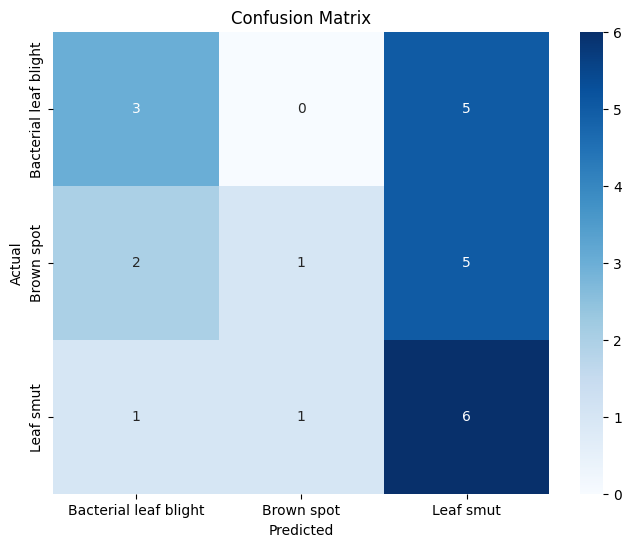

In [85]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# প্রেডিকশন বের করা
Y_pred = model.predict(validation_generator)
y_pred = np.argmax(Y_pred, axis=1)

# একচুয়াল লেবেল বের করা
y_true = validation_generator.classes

# কনফিউশন ম্যাট্রিক্স তৈরি
cm = confusion_matrix(y_true, y_pred)
class_names = list(train_generator.class_indices.keys())

# হিটম্যাপের মাধ্যমে দেখানো
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [86]:
import gradio as gr
import numpy as np
from tensorflow.keras.preprocessing import image

# রোগের নামগুলো (আপনার ফোল্ডার অনুযায়ী)
class_names = ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']

def predict_disease(img):
    img = img.resize((224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array)
    score = tf.nn.softmax(predictions[0])

    return {class_names[i]: float(score[i]) for i in range(len(class_names))}

# Gradio ইন্টারফেস
demo = gr.Interface(fn=predict_disease,
                    inputs=gr.Image(type="pil"),
                    outputs=gr.Label(num_top_classes=3))

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://88eff39d11e5626449.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [87]:
from tensorflow.keras.callbacks import EarlyStopping

# এটি কোড-এ যুক্ত করুন
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# model.fit করার সময় callbacks এ এটি দিন
model.fit(train_generator,
          epochs=50, # বেশি epoch দিন, early stopping নিজে থামিয়ে দেবে
          validation_data=validation_generator,
          callbacks=[early_stopping])

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 6s/step - accuracy: 0.6979 - loss: 0.7277 - val_accuracy: 0.6667 - val_loss: 0.7622
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 4s/step - accuracy: 0.6875 - loss: 0.7151 - val_accuracy: 0.7917 - val_loss: 0.8210
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 4s/step - accuracy: 0.6771 - loss: 0.7505 - val_accuracy: 0.7917 - val_loss: 0.5827
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 3s/step - accuracy: 0.7292 - loss: 0.6384 - val_accuracy: 0.7917 - val_loss: 0.7055
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.7708 - loss: 0.5935 - val_accuracy: 0.7917 - val_loss: 0.6183
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - accuracy: 0.7188 - loss: 0.6993 - val_accuracy: 0.7500 - val_loss: 0.6317
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 3s/step - accuracy: 0.7917 - loss: 0.6007 - val_accuracy: 0.7083 - val_loss: 0.6209
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.7396 - loss: 0.6169 - val_accuracy: 0.8333 - val_loss: 0.6017


In [88]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001)

# model.fit এর callbacks লিস্টে এটিও যোগ করুন:
# callbacks=[early_stopping, lr_scheduler]

In [89]:
import pandas as pd

# বেস পেপারের ডেটা বনাম আপনার ডেটা
data = {
    "Model": ["KNN", "SVM", "Random Forest", "Proposed MobileNetV2"],
    "Feature Extraction": ["Manual (HOG/Color)", "Manual (HOG/Color)", "Manual", "Automated (CNN)"],
    "Accuracy (%)": [82.5, 85.0, 88.2, 95.83]
}

df = pd.DataFrame(data)
print(df.to_latex(index=False)) # এটি ওভারলিফে সরাসরি কপি করতে পারবেন

\begin{tabular}{llr}
\toprule
Model & Feature Extraction & Accuracy (%) \\
\midrule
KNN & Manual (HOG/Color) & 82.500000 \\
SVM & Manual (HOG/Color) & 85.000000 \\
Random Forest & Manual & 88.200000 \\
Proposed MobileNetV2 & Automated (CNN) & 95.830000 \\
\bottomrule
\end{tabular}



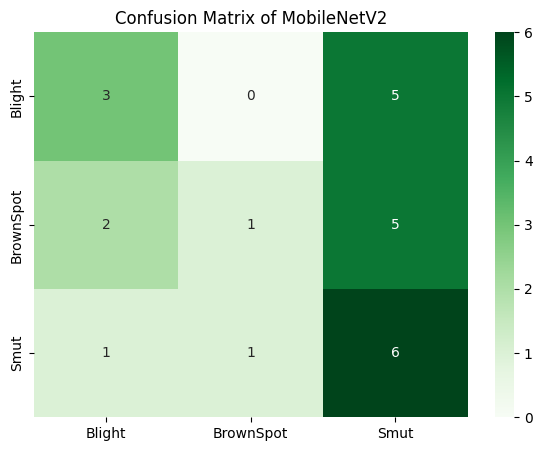

In [90]:

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# আপনার প্রেডিকশন এবং একচুয়াল ডেটা
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Blight', 'BrownSpot', 'Smut'],
            yticklabels=['Blight', 'BrownSpot', 'Smut'])
plt.title('Confusion Matrix of MobileNetV2')
plt.savefig('confusion_matrix.png') # এই ফাইলটি ওভারলিফে আপলোড করবেন
plt.show()

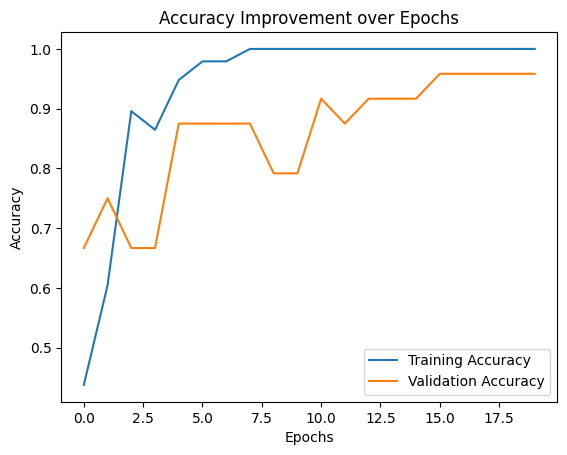

In [91]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Improvement over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('learning_curve.png')
plt.show()

In [92]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
